# Authoritative card catalog exploration

This notebook is a narrative consumer of the tested `Catalog` interface. It does not reimplement CSV parsing or validation.

In [1]:
from collections import Counter
from dataclasses import asdict
from pathlib import Path

from fall_ai_studio.catalog import load_catalog

SOURCE = Path('../data/pokemon-tcg-ai-battle-challenge-strategy/EN Card Data.csv')
catalog = load_catalog(SOURCE)
asdict(catalog.source)

{'path': '../data/pokemon-tcg-ai-battle-challenge-strategy/EN Card Data.csv',
 'sha256': '507d8d670c9c3c8d58f400d42eed09270b6b01354332770081bdb455d53b8c84',
 'row_count': 2022,
 'card_count': 1267}

The Source Receipt ties every observation below to the unchanged September input. The 2,022 rows aggregate into 1,267 Card Records because cards may have several action rows.

In [2]:
action_counts = Counter(len(card.actions) for card in catalog.cards.values())
dict(sorted(action_counts.items()))

{0: 8, 1: 536, 2: 691, 3: 32}

In [3]:
Counter(card.stage_or_type for card in catalog.cards.values()).most_common()

[('Basic Pokémon', 595),
 ('Stage 1 Pokémon', 345),
 ('Stage 2 Pokémon', 116),
 ('Item', 77),
 ('Supporter', 61),
 ('Pokémon Tool', 27),
 ('Stadium', 26),
 ('Special Energy', 12),
 ('Basic Energy', 8)]

In [4]:
fields = ('previous_stage', 'hp', 'card_type', 'weakness', 'resistance')
{field: sum(getattr(card, field) is None for card in catalog.cards.values()) for field in fields}

{'previous_stage': 801,
 'hp': 206,
 'card_type': 191,
 'weakness': 246,
 'resistance': 1047}

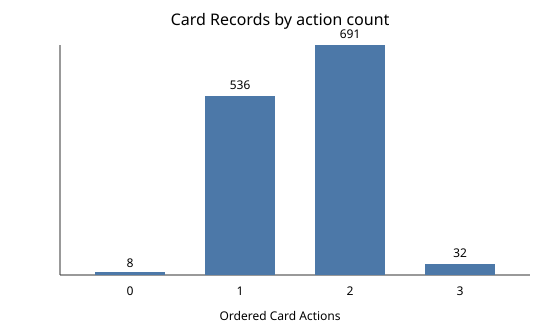

In [5]:
import matplotlib.pyplot as plt

figure, axis = plt.subplots(figsize=(5.6, 3.3))
axis.bar(action_counts.keys(), action_counts.values(), color='#4c78a8')
axis.set(title='Card Records by action count', xlabel='Ordered Card Actions', ylabel='Records')
axis.set_xticks(sorted(action_counts))
for action_count, records in sorted(action_counts.items()):
    axis.text(action_count, records + 12, str(records), ha='center')
figure.tight_layout()

## Findings and limits

- Eight records have no action; the Catalog preserves them rather than inventing one.
- Repeated source rows describe ordered actions, not duplicate cards. The loader also rejects disagreement in repeated card-level fields.
- Missingness is structural: Energy and Trainer records do not share every Pokémon field. A blank value should not be imputed without a gameplay-specific reason.
- The primary export's `Previos stage` header is normalized in memory; the source file is not edited.
- The similarly named alternate English export is not used because it changes values as well as formatting.
- This card snapshot describes the available pool. It is not match-state data and supports no claim about agent performance.